In [1]:
import pandas as pd
import numpy as np

from rdkit.Chem import Draw, MolFromSmiles, ReplaceSubstructs, RemoveAllHs, FragmentOnBRICSBonds, GetMolFrags, MolToSmiles
from IPython.display import SVG
from collections import defaultdict

In [2]:
def visualize_contributions(smiles, 
                            contributions, 
                            scale=0.5):
    '''
        Visualizes the contribution of with circles. Uses rdKit. Draw to create a SVG. Contributions are highlighted using circles of different colours, the radius scaling accoringly to the contribution

        input:
            smiles: str, SMILES of the molecule
            contributions: np.array, array containing the contributions per atom
            scaler: float, controls the scaling of the radius of the circles drawn. Needs to be adjusted accordingly
    '''
    radii = {}
    colors = {}
    highlight_atoms = []
    for i,cont in enumerate(contributions):
        # quantize and scale the charge so that we can use it to scale the highlight radii
        #chg = (10*chg//1)/10
        if abs(cont)>1e-4:
            radii[i] = abs(cont) * scale
            highlight_atoms.append(i)
            if cont>0:
                colors[i] = (1,.5,.5)
            else:
                colors[i] = (.5,.5,1)

    d2d = Draw.MolDraw2DSVG(-1, -1)
    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    # we need to set the highlights to be circles or we'll end up with ovals
    # that fit around the atomic symbol
    dopts.atomHighlightsAreCircles = True

    # we need to provide highlightBonds=[] here to avoid having the bonds between highlighted atoms highlighted:
    d2d.DrawMolecule(MolFromSmiles(smiles),
                     highlightAtoms=highlight_atoms,
                     highlightAtomColors=colors,
                     highlightAtomRadii=radii,
                     highlightBonds=[])
    d2d.FinishDrawing()
    return SVG(d2d.GetDrawingText())

In [3]:
def get_atom_contribution_from_result_dict(smiles, results_dict, frag_to_atom_ids):
    '''
        Converts the contribution per fragment to contirbution per atom by assining each atom in the molecule the contribution of the whole fragment
        ###ADD NORMALIZATION!!!!###

        input:
            smiles: str, SMILES of the whole molecule
            results_dict: Dict[int, float], containing the contribution of the indivdual fragments
            frag_to_atom_ids: Dict[int, List[int]], containing a mapping of each frag id to atom id

        output
            np.array, containing the contributions distributed along all atoms
    '''
    contributions = np.zeros(MolFromSmiles(smiles).GetNumAtoms())
    for frag_id in range(len(results_dict.keys())):
        for atom_id in frag_to_atom_ids[frag_id]:
            contributions[atom_id] = results_dict[frag_id]
    return contributions

In [4]:
# load exemplary data
df = pd.read_pickle('rf_regression_solubility/df_explanation.pkl')
df['n_fragments'] = df.fragExplainer_result.apply(lambda x: len(x.keys()))

row = df.sort_values(by='n_fragments', ascending=False).iloc[0]
row

model                                                                          RF
dataset                                                              esol_delaney
split                                                                           4
smiles                                           CCCCOc1ccc(C(=O)OCC)c(N(CC)CC)c1
y_true                                                                      -3.84
y_pred                                                                  -4.054065
fragExplainer_result            {0: -1.0490428293650782, 1: 0.1517015992063492...
fragExplainer_expected_value                                              -1.0454
shap_result                     [0.0, 0.032656022456721986, 0.0013081494522339...
shap_expected_value                                                     -3.029359
atom_id_to_bits                 {3: [13, 80, 1873], 7: [67, 1750, 1873], 1: [8...
frag_to_atom_ids                {0: [0, 1, 2, 3], 1: [4], 2: [5, 6, 7, 8, 14, ...
n_fragments     

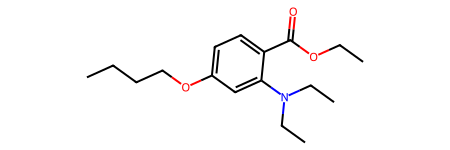

In [5]:
smiles = row.smiles
y_pred = row.y_pred
fE_ev = row.fragExplainer_expected_value
fE_result = row.fragExplainer_result
shap_ev = row.shap_expected_value
shap_result = row.shap_result
atom_id_to_bits = row.atom_id_to_bits
frag_to_atom_ids = row.frag_to_atom_ids

MolFromSmiles(row.smiles)

In [6]:
# check properties
assert np.allclose(np.sum([v for v in fE_result.values()]) + fE_ev, y_pred)
assert np.allclose(shap_ev + shap_result.sum(), y_pred)

# Visualize using fragExplainer output

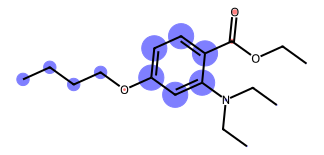

In [7]:
contributions = get_atom_contribution_from_result_dict(smiles=smiles,
                                                        results_dict=fE_result,
                                                        frag_to_atom_ids=frag_to_atom_ids)

visualize_contributions(smiles=smiles,
                        contributions=contributions,
                        scale=0.3)

In [8]:
print(f'Contributions from Fragments: {sum(fE_result.values()):.3f}')
print(f'Expected value: {fE_ev:.3f}')

Contributions from Fragments: -3.009
Expected value: -1.045


# Visualizing using SHAP output

In [9]:
# invert atom_id_to_bits to bits_to_atom_ids
def get_bits_to_atom_ids(atom_id_to_bits):

    bits_to_atom_ids = defaultdict(list)
    for k, values in atom_id_to_bits.items():
        for v in values:
            bits_to_atom_ids[v].append(k)
    return bits_to_atom_ids

In [10]:
def get_atom_contribution_from_shap_results(atom_id_to_bits, shap_result, bits_to_atom_ids):
    contributions = np.zeros(len(atom_id_to_bits))
    for atom_id in atom_id_to_bits.keys():
        for bit in atom_id_to_bits[atom_id]:
            contributions[atom_id] += shap_result[bit] / len(bits_to_atom_ids[bit])
    return contributions

In [11]:
bits_to_atom_ids = get_bits_to_atom_ids(atom_id_to_bits)
contributions_shap = get_atom_contribution_from_shap_results(atom_id_to_bits,
                                                             shap_result,
                                                             bits_to_atom_ids)

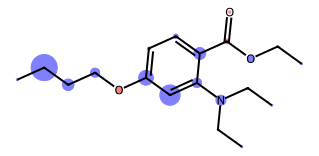

In [12]:
visualize_contributions(smiles=smiles,
                        contributions=contributions_shap,
                        scale=2)

In [13]:
print(f'Contribution from present bits: {sum(contributions_shap):.3f}')
print(f'Contribution from absent bits: {sum(shap_result)-sum(contributions_shap):.3f}')
print(f'Expected Value: {shap_ev:.3f}')

Contribution from present bits: -1.573
Contribution from absent bits: 0.548
Expected Value: -3.029


# Converting SHAP output to fragExplainer output

In [14]:
# distribute the fragment contribution on all the atoms in the fragment equally

def convert_shap_to_fragment_contribution(atom_id_to_bits,
                                          bits_to_atom_ids,
                                          shap_result):
    bits_to_atom_ids = get_bits_to_atom_ids(atom_id_to_bits)
    contributions_shap = get_atom_contribution_from_shap_results(atom_id_to_bits,
                                                                 shap_result,
                                                                 bits_to_atom_ids)
    

    contributions_shap_to_frag = np.zeros(len(atom_id_to_bits.keys()))
    for atom_ids_frag in frag_to_atom_ids.values():
        for atom_id in atom_ids_frag:
            contributions_shap_to_frag[atom_id] = contributions_shap[np.array(atom_ids_frag)].mean()
    return contributions_shap_to_frag

In [15]:
bits_to_atom_ids = get_bits_to_atom_ids(atom_id_to_bits)
contributions_shap_to_frag = convert_shap_to_fragment_contribution(atom_id_to_bits,
                                                                   bits_to_atom_ids,
                                                                   shap_result)

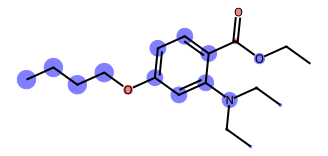

In [16]:
visualize_contributions(smiles=smiles,
                        contributions=contributions_shap_to_frag,
                        scale=3)

In [17]:
# get it in default dict format for easier comparison

In [18]:
bits_to_atom_ids = get_bits_to_atom_ids(atom_id_to_bits)

In [31]:
def get_frag_dict_from_shap_result(frag_to_atom_ids,
                                   bits_to_atom_ids,
                                   atom_id_to_bits,
                                   shap_result):

    shap_to_fE = defaultdict(float)
    for frag_id, atom_ids_frag in frag_to_atom_ids.items():
        # print(frag_id, atom_ids_frag)
        for atom_id in atom_ids_frag:
            for bit in atom_id_to_bits[atom_id]:
                # print(bit, len(bits_to_atom_ids[bit]))
                shap_to_fE[frag_id] += shap_result[bit] / len(bits_to_atom_ids[bit])
    return shap_to_fE

In [32]:
bits_to_atom_ids[294]

[0, 13, 17, 19]

In [33]:
shap_to_fE = get_frag_dict_from_shap_result(frag_to_atom_ids,
                                            bits_to_atom_ids,
                                            atom_id_to_bits,
                                            shap_result)

In [37]:
shap_to_fE

defaultdict(float,
            {0: np.float64(-0.6220958374779788),
             1: np.float64(0.07498305568265351),
             2: np.float64(-0.8075561503503855),
             3: np.float64(0.08938351971684369),
             4: np.float64(-0.08731873070225418),
             5: np.float64(-0.007378864249559741),
             6: np.float64(-0.12646960014641992),
             7: np.float64(-0.04314683838336265),
             8: np.float64(-0.04314683838336265)})

In [38]:
fE_result

defaultdict(float,
            {0: np.float64(-1.0490428293650782),
             1: np.float64(0.1517015992063492),
             2: np.float64(-2.137051746031745),
             3: np.float64(0.3493843968253977),
             4: np.float64(-0.0070899484126985685),
             5: np.float64(-0.014432591269841408),
             6: np.float64(-0.16517903174603163),
             7: np.float64(-0.06847742460317431),
             8: np.float64(-0.06847742460317431)})

In [42]:
list(fE_result.values())

[np.float64(-1.0490428293650782),
 np.float64(0.1517015992063492),
 np.float64(-2.137051746031745),
 np.float64(0.3493843968253977),
 np.float64(-0.0070899484126985685),
 np.float64(-0.014432591269841408),
 np.float64(-0.16517903174603163),
 np.float64(-0.06847742460317431),
 np.float64(-0.06847742460317431)]

In [46]:
from scipy.stats import pearsonr, spearmanr

print(pearsonr(list(fE_result.values()), list(shap_to_fE.values())))
print(spearmanr(list(fE_result.values()), list(shap_to_fE.values())))

PearsonRResult(statistic=np.float64(0.9735354903405793), pvalue=np.float64(9.67460127065145e-06))
SignificanceResult(statistic=np.float64(0.8991596638655464), pvalue=np.float64(0.0009702694880889046))


Think about adding bonds for fragments and so on... Maybe using highlightBond[Colors]
https://rdkit.blogspot.com/2020/10/molecule-highlighting-and-r-group.html